# 🚁 Drone Intelligence: Adaptive Terrain Classification


## I. Perkenalan
    Risyadhana Syafuddin | Batch HCK-036 | 2026

###1.1 Background

Di era industri 4.0, penggunaan drone untuk pemetaan wilayah (geospasial) dan pengawasan infrastruktur telah menjadi standar baru yang meningkatkan efisiensi secara signifikan. Namun, tantangan utama dalam klasifikasi gambar otomatis oleh drone adalah reliabilitas. Seringkali model AI mengalami "halusinasi" atau salah klasifikasi ketika melihat objek di luar kategori yang dipelajari (Out-of-Distribution). Sebagai contoh, seekor harimau di tengah hutan bisa dideteksi sebagai Glacier atau Mountain karena pola tekstur lorengnya menyerupai retakan es atau bayangan bebatuan. That's why, itu  merupakan problem. sehingga bisa dibilang ini bukan sekadar soal angka akurasi di atas kertas, melainkan soal keamanan operasional dan integritas data laporan. Jika drone salah mengidentifikasi objek asing sebagai medan tertentu, keputusan logistik atau navigasi di lapangan bisa berakibat fatal.

###1.2 Dataset Overview

Dataset yang digunakan dalam proyek ini adalah Intel Image Classification, yang mencakup sekitar 25.000 gambar pemandangan alam berukuran 150x150 piksel. Data ini merepresentasikan citra udara yang umumnya ditangkap oleh sensor drone, yang dibagi menjadi 6 kategori utama:

> 1. Buildings: Area perkotaan, gedung, dan infrastruktur buatan manusia.

> 2. Forest: Vegetasi hutan lebat dan area hijau luas.

> 3. Glacier: Formasi es alami dan hamparan salju.

> 4. Mountain: Struktur pegunungan batu atau tanah yang menonjol.

> 5. Sea: Area perairan laut dan samudera.

> 6. Street: Infrastruktur jalan raya dan jalur transportasi.

###1.3 Objective

Saya membuat proyek ini untuk membangun solusi cerdas bagi navigasi drone dengan rincian sebagai berikut:

> 1. High Precision Mapping: Membangun model Deep Learning berbasis Convolutional Neural Network (CNN) yang mampu mengklasifikasikan 6 kategori medan dengan tingkat akurasi tinggi (>90%).

> 2. Confidence Thresholding Mechanism: Mengimplementasikan sistem filtrasi berbasis probabilitas untuk mendeteksi objek asing.

> 3. Fail-Safe Labeling: Jika tingkat keyakinan model di bawah batas tertentu (threshold), objek akan dilabeli sebagai "Tidak Terdefinisi / Objek Asing" guna menjamin keamanan operasional drone dan mencegah salah informasi pada laporan akhir.

## II. Import Libraries

In [1]:
# Standard libraries untuk pengolahan data dan OS
import os
import random
import warnings
import numpy as np
import pandas as pd

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

# Framework utama Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, GlobalAveragePooling2D,
                                     BatchNormalization, Input)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import Xception

# Library untuk evaluasi model (BAGIAN YANG DIPERBAIKI)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Mematikan peringatan yang tidak perlu
warnings.filterwarnings('ignore')

## III. Data Loading

In [2]:
# Image Processing

import kagglehub

# Download dataset secara otomatis dari Kaggle
# Dataset: Intel Image Classification (puneet6060)
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path ke dataset:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path ke dataset: /kaggle/input/intel-image-classification


In [3]:
# inisiasi train_path, dan test_path training dan testing
# dengan mendownload folder 'seg_train' di dalam root path
train_path = os.path.join(path, 'seg_train/seg_train')
test_path = os.path.join(path, 'seg_test/seg_test')

In [4]:
# inisiasi untuk verifikasi folder kategori
classes = sorted(os.listdir(train_path))
print(f"Kategori yang ditemukan (sesuai abjad): {classes}")

Kategori yang ditemukan (sesuai abjad): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [5]:
# fungsi untuk mengecek jumlah data di setiap kategori
def check_data_size(dir_path, labels):
    data_counts = []
    for label in labels:
        count = len(os.listdir(os.path.join(dir_path, label)))
        data_counts.append(count)
        print(f"Total gambar di kelas {label.upper()}: {count}")
    return data_counts

In [6]:
print("\n >>> TRAIN SET <<<")
train_counts = check_data_size(train_path, classes)

print("\n >>> TEST SET <<<")
test_counts = check_data_size(test_path, classes)


 >>> TRAIN SET <<<
Total gambar di kelas BUILDINGS: 2191
Total gambar di kelas FOREST: 2271
Total gambar di kelas GLACIER: 2404
Total gambar di kelas MOUNTAIN: 2512
Total gambar di kelas SEA: 2274
Total gambar di kelas STREET: 2382

 >>> TEST SET <<<
Total gambar di kelas BUILDINGS: 437
Total gambar di kelas FOREST: 474
Total gambar di kelas GLACIER: 553
Total gambar di kelas MOUNTAIN: 525
Total gambar di kelas SEA: 510
Total gambar di kelas STREET: 501


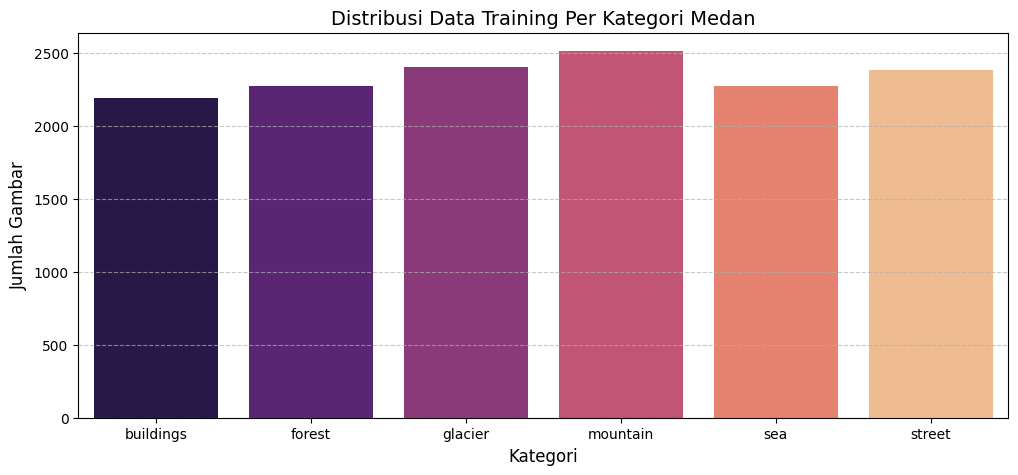

In [7]:
# Visualisasi distribusi data untuk cek imbalance
plt.figure(figsize=(12, 5))
sns.barplot(x=classes, y=train_counts, palette='magma')
plt.title('Distribusi Data Training Per Kategori Medan', fontsize=14)
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah Gambar', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
# inisiasi untuk menampilkan informasi resolusi gambar contoh
sample_img_path = os.path.join(train_path, 'buildings', os.listdir(train_path + '/buildings')[0])
sample_img = plt.imread(sample_img_path)
print(f"\nMetadata Gambar Contoh: Resolusi {sample_img.shape[1]}x{sample_img.shape[0]}, Kanal {sample_img.shape[2]} (RGB)")


Metadata Gambar Contoh: Resolusi 150x150, Kanal 3 (RGB)


## IV. Exploratory Data Analysis (EDA)

  Pada bagian ini saya menganalisis karakteristik visual dari 6 medan untuk memahami bagaimana filter konvolusi bekerja nantinya.Sehingga, drone menangkap data berdasarkan intensitas warna dan pola tekstur. Analisis ini akan menjadi dasar mengapa pada analisa ini memerlukan arsitektur CNN yang spesifik.

### 4.1 Visualisasi Sampel Setiap Kategori

Pada tahap ini, saya melihat data asli untuk memahami variasi sudut pandang drone.

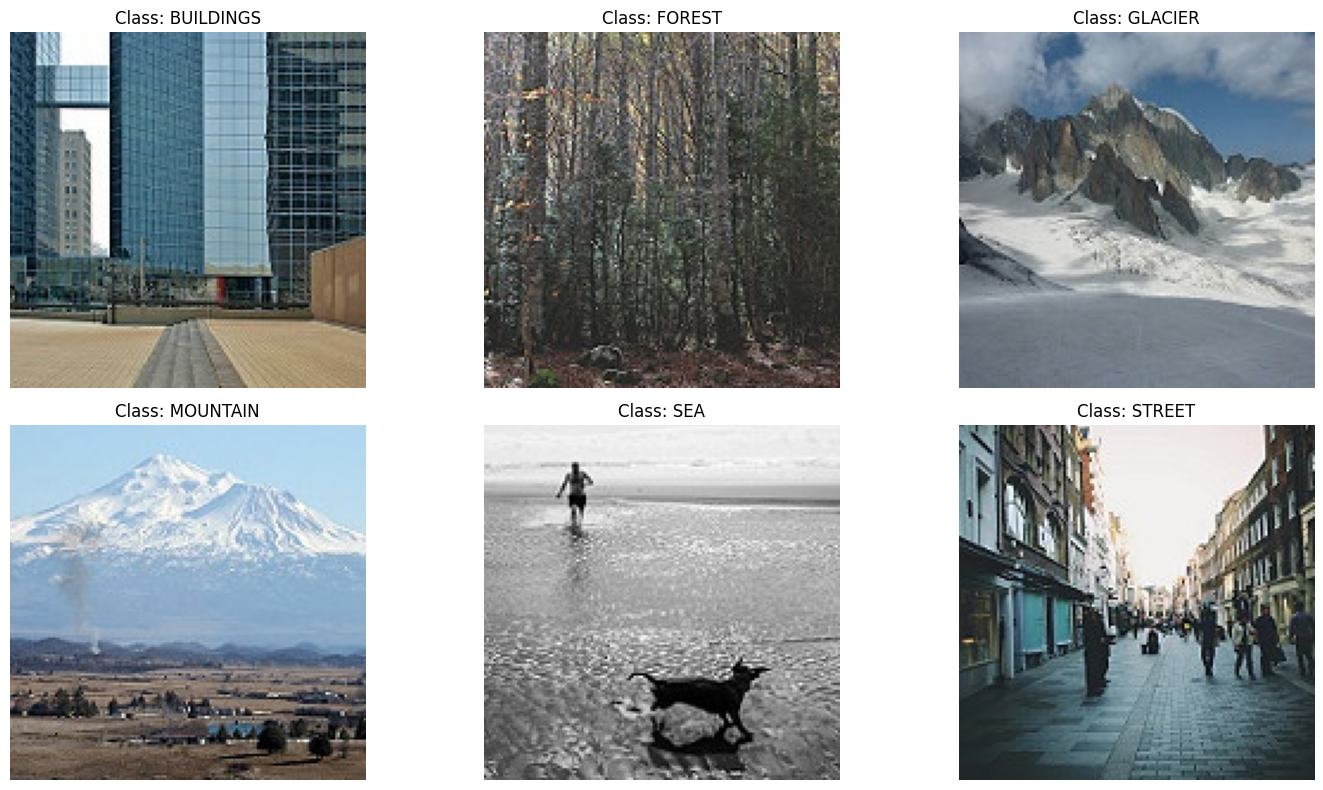

In [9]:
# Fungsi untuk menampilkan grid gambar dari setiap kelas
def plot_categorical_samples(directory, labels):
    plt.figure(figsize=(15, 8))
    for i, label in enumerate(labels):
        folder_path = os.path.join(directory, label)
        img_name = random.choice(os.listdir(folder_path)) # Ambil gambar acak
        img_path = os.path.join(folder_path, img_name)
        img = plt.imread(img_path)

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"Class: {label.upper()}", fontsize=12)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_categorical_samples(train_path, classes)

  > 1. Didapati bahwa buildings & street memiliki garis geometris tegas (tepi vertikal/horizontal).

  > 2. Selain itu, didapati bahwa fores mendominasi kanal Green dengan tekstur organik yang sangat acak (noise).

  > 3. Sedangkan glacier & mountain, didapati bahwa keduanya memiliki pola fraktal yang mirip. Contoh pada loreng Harimau secara visual meniru pola fraktal ini, bisa dibilang mimikri, yang berpotensi mengecoh model jika hanya mengandalkan fitur tekstur tanpa filter warna/probabilitas yang ketat.

### 4.2 Analisis Distribusi Warna (Color Histogram)

Dari proses sebelumnya, saya berasumsi bahwa drone biasanya sering menghadapi masalah pencahayaan. Dengan melihat histogram, saya bisa tahu kelas mana yang memiliki profil warna serupa.

  > 1. Pada Sea & Glacier akan memiliki puncak di kanal Blue.

  > 2. Forest akan memiliki dominasi di kanal Green.

  > 3. Buildings & Street, bisa dibilang cenderung memiliki distribusi warna yang lebih rata (keabu-abuan)

Oleh karena itu, saya mau menampilkan satu sampel dari tiap kelas untuk melihat perbedaan tepi (edge)

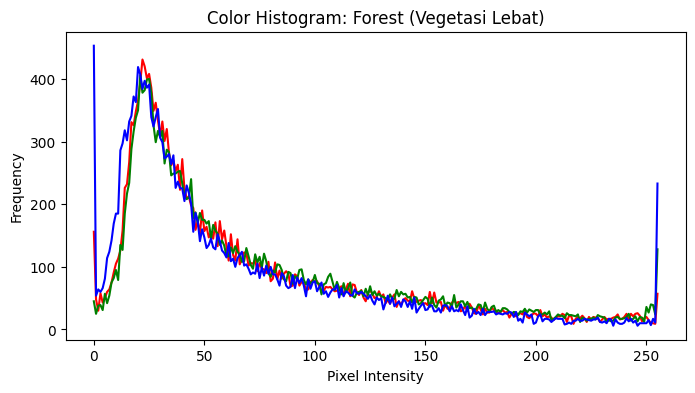

In [10]:
def plot_color_histogram(image_path, title):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    colors = ('r', 'g', 'b')
    plt.figure(figsize=(8, 4))
    for i, col in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=col)
    plt.title(f"Color Histogram: {title}")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

# Contoh: Analisis warna Forest
forest_sample = os.path.join(train_path, 'forest', os.listdir(train_path+'/forest')[0])
plot_color_histogram(forest_sample, "Forest (Vegetasi Lebat)")

### 4.3. Analisis Tekstur: Tepi dan Kontur (Edge Detection)

Pada tahap ini, bagian paling penting terkait kasus "Harimau". AI mendeteksi objek melalui filter konvolusi yang mencari Edge (tepi).

  > Man-made (Buildings/Street) memiliki garis-garis lurus dan sudut tajam.

  > Natural (Mountain/Glacier/Forest) memiliki tekstur Fractal (acak namun berulang). Sehingga loreng harimau memiliki frekuensi spasial yang sangat mirip dengan retakan es atau bayangan bebatuan gunung.

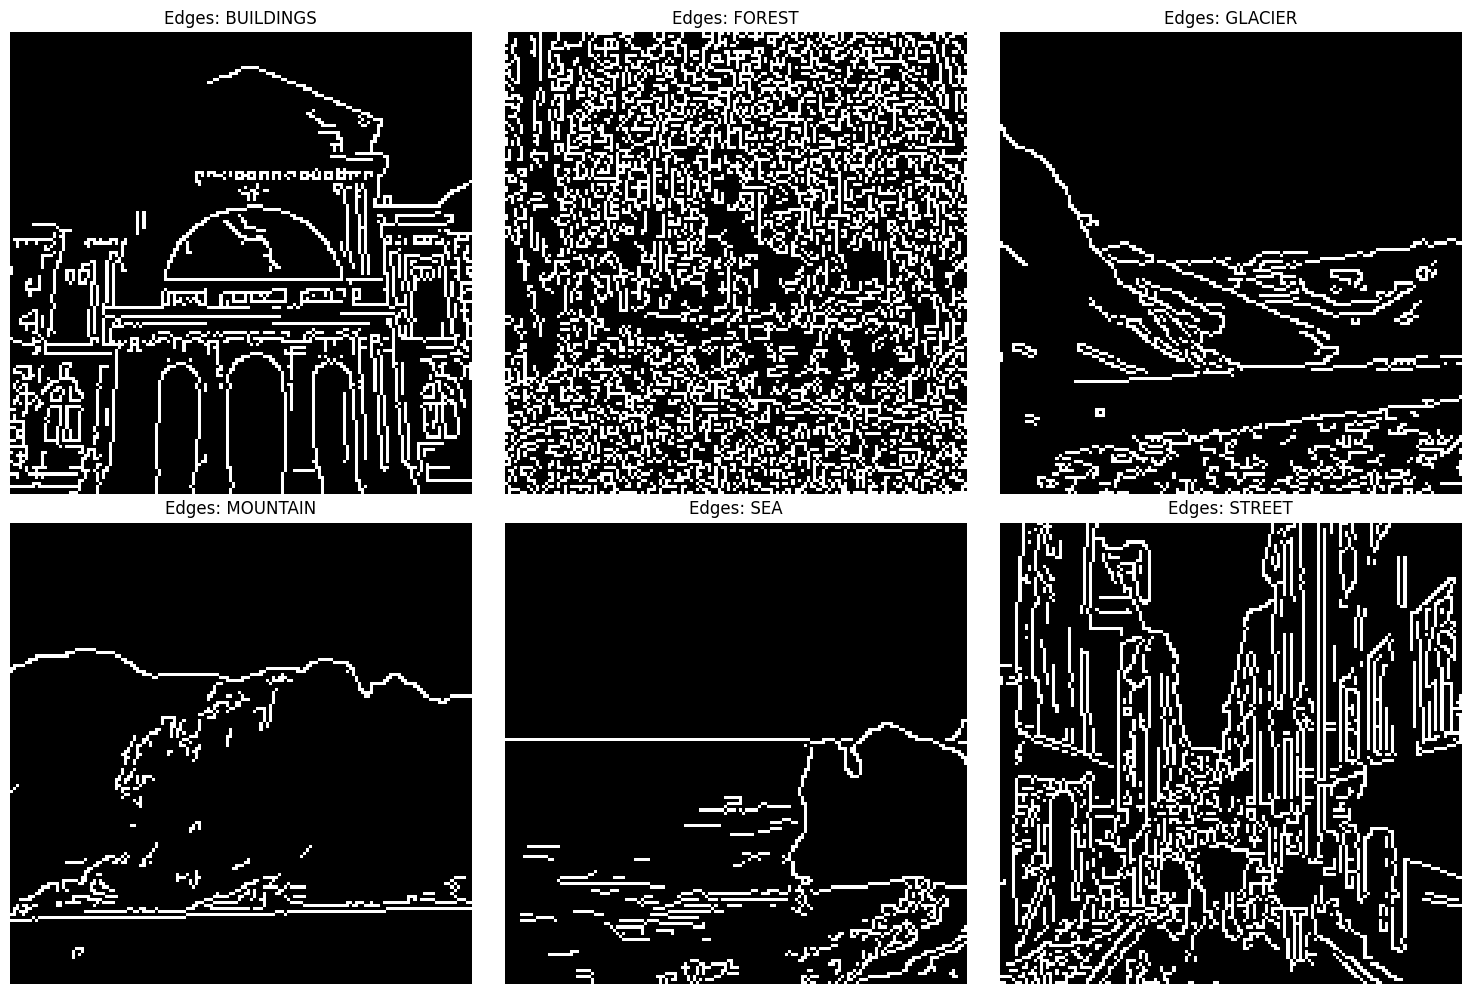

In [11]:
def plot_edge_analysis(directory, categories):
    plt.figure(figsize=(15, 10))
    for i, cat in enumerate(categories):
        img_name = os.listdir(os.path.join(directory, cat))[5]
        img = cv2.imread(os.path.join(directory, cat, img_name), 0) # Load grayscale
        edges = cv2.Canny(img, 100, 200) # Algoritma Canny untuk deteksi tepi

        plt.subplot(2, 3, i+1)
        plt.imshow(edges, cmap='gray')
        plt.title(f"Edges: {cat.upper()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_edge_analysis(train_path, classes)

### 4.4. Kesimpulan Insight EDA

Berdasarkan eksplorasi di atas, didapatkan poin-poin penting:

> 1. High Similarity: Kelas Glacier dan Mountain memiliki kemiripan struktur tepi yang sangat tinggi. Model membutuhkan filter konvolusi yang lebih dalam untuk membedakan tekstur salju vs batu.

> 2. Man-Made vs Natural: Kelas Buildings dan Street dapat dibedakan dengan mudah melalui pola garis lurus.

> 3. Kasus Objek Asing (Harimau): Secara visual, pola loreng hewan akan menghasilkan deteksi tepi yang sangat mirip dengan kelas Mountain atau Glacier pada analisis Canny Edge. Namun, pada analisis warna (Histogram), objek asing biasanya memiliki lonjakan warna (seperti Orange pada harimau) yang tidak masuk dalam distribusi normal 6 kelas ini.

> 4. Strategi: Insight ini memperkuat alasan penggunaan Confidence Thresholding. Jika model mendeteksi tekstur "gunung" tapi skor probabilitasnya rendah (karena warnanya aneh), model harus berani melabeli sebagai "Tidak Terdefinisi".

## V. Feature Engineering

Pada bagian ini, saya melakukan proses penyiapan data supaya nantinya model memiliki kemampuan generalisasi yang tinggi. Dikarenakan drone beroperasi di lingkungan yang dinamis, mulai dari segi perubahan cahaya, sudut pandang, guncangan, dan ketinggian yang bervariasi. Sehingga bisa dibilang data asli perlu dimanipulasi, supaya model tidak hanya "menghafal" gambar, tetapi benar-benar "belajar" pola fitur.

### 5.1. Image Augmentation Strategy

Saya menggunakan teknik Image Augmentation melalui ImageDataGenerator. Strategi ini krusial, karena drone di lapangan tidak selalu menangkap gambar dalam kondisi sempurna.

Parameter augmentasi yang saya gunakan:

  > 1. Pada proses rescale (1./255), saya mengubah nilai piksel dari range 0-255 menjadi 0-1. Bisa dibilang, Ini membantu fungsi aktivasi (seperti ReLU) dan optimizer (Adam) untuk bekerja lebih efisien tanpa ledakan gradien.

  > 2. Pada proses rotation range (25), saya mensimulasikan kondisi drone yang miring (tilt) saat bermanuver atau tertiup angin.

  > 3. Pada tahap width & height shift (0.2), saya mensimulasikan objek yang tidak selalu berada di tengah frame kamera drone.

  > 4. Pada tahap shear & soom Range (0.2), saya mensimulasikan perubahan perspektif dan jarak (ketinggian) drone terhadap objek di permukaan tanah.

  > 5. Selain itu, pada proses horizontal flip, saya mengasumsikan bahwa fitur geografis seperti gunung atau hutan tetap valid meskipun dilihat dari arah berlawanan.

  > 6. Dan yang terakhir pada proses validation s-plit (0.2), saya memecah data menjadi 80% untuk pelatihan (train) dan 20% untuk validasi (val) dengan memonitor performa model pada data yang belum pernah dilihat sebelumnya.

In [12]:
# inisiasi datagen untuk mendefinisikan generator dengan augmentasi untuk data training dan validasi
datagen = ImageDataGenerator(
    rescale=1./255,           # Normalisasi nilai piksel
    rotation_range=15,        # Rotasi gambar
    width_shift_range=0.1,    # Pergeseran horizontal
    height_shift_range=0.1,   # Pergeseran vertikal
    shear_range=0.1,          # Pergeseran sudut pandang
    zoom_range=0.1,           # Perubahan jarak/zoom-
    horizontal_flip=True,     # Pembalikan horizontal
    brightness_range=[0.9, 1.1],
    fill_mode='nearest',      # Mengisi piksel kosong akibat transformasi
    validation_split=0.2      # Split 20% untuk validasi
)

# ImageDataGenerator untuk data testing (bisa dibilang just Rescale, tanpa augmentasi)
# saya melakukan test, karena bisa dibilang menjadi hal yang penting supaya evaluasi akhir dapat mencerminkan performa pada data asli di lapangan
test_datagen = ImageDataGenerator(rescale=1./255)

### 5.2. Data Generator Implementation

Pada tahap ini, saya ingin menganalisa apakah data yang dialirkan langsung dari direktori dengan target size $150 \times 150$ piksel, sesuai dengan resolusi asli dataset yang telah divalidasi pada tahap Data Loading.

In [13]:
# inisiasi train_gen untuk training generator
train_gen = datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

# inisiasi val_gen untuk validation generator
val_gen = datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42
)

# inisiasi test_gen untuk testing generator
test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Shuffle False supaya urutan label saat evaluasi tidak berantakan
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


### 5.3. Mapping Label & Class Indices

In [14]:
# inisiasi class_indicaes untuk mendapatkan dictionary index kelas
class_indices = train_gen.class_indices
# inisiasi labels untuk membalikkan dictionary untuk keperluan inferensi (Index -> Name)
labels = {v: k for k, v in class_indices.items()}

print("Pemetaan Label:")
for idx, name in labels.items():
    print(f"Index {idx} -> {name.upper()}")

Pemetaan Label:
Index 0 -> BUILDINGS
Index 1 -> FOREST
Index 2 -> GLACIER
Index 3 -> MOUNTAIN
Index 4 -> SEA
Index 5 -> STREET


Pada proses feature engineering di atas dirancang untuk menciptakan model yang Robust. Dengan memberikan variasi posisi dan sudut pada data training, sehingga bisa dibilang model akan dipaksa untuk fokus pada fitur utama (misalnya: tekstur hijau untuk forest atau garis lurus untuk buildings) daripada hanya menghafal komposisi gambar.

Sehingga didapati pemisahan data secara eksplisit menggunakan validation_split sebagai langkah preventif terhadap overfitting. Jika model hanya akurat di data training tetapi gagal di data validasi, sehingga bisa dibilang augmentasi perlu disesuaikan atau arsitektur model perlu diperbaiki sebelum masuk ke tahap modeling.

## VI. ANN Training (Sequential API)

Pada tahap ini, saya membangun arsitektur CNN dari nol (from scratch) menggunakan Sequential API. Sehingga model ini dirancang untuk mempelajari fitur spasial dasar seperti tepian, warna, dan pola tekstur dari citra drone.

### 6.1. Model Definition

Saya melakukan analisa terhadap arsitektur model

  > 1. Didapati bahwa convolutional layers, terdiri dari 3 blok konvolusi dengan peningkatan filter (32, 64, 128). Hal ini bertujuan supaya model bisa mempelajari fitur dari yang sederhana (garis) hingga yang kompleks (objek/medan).

  > 2. Selain itu, didapati juga MaxPooling2D, yang prosesnya digunakan setelah setiap lapisan konvolusi untuk mereduksi dimensi gambar (downsampling) sehingga model lebih fokus pada fitur yang paling menonjol dan mengurangi beban komputasi.

  > 3. Didapati juga BatchNormalization yang berfungsi untuk menstabilkan proses training dengan menormalkan output dari layer sebelumnya, sehingga model konvergen lebih cepat.

  > 4. Namun saya melakukan Dropout (0.5) yang diterapkan sebelum layer output untuk mencegah overfitting dengan cara mematikan 50% neuron secara acak selama training.

  > 5. Sehingga pada tahapan Output Layer, saya menggunakan 6 neuron (sesuai jumlah kelas) dengan fungsi aktivasi Softmax untuk menghasilkan probabilitas klasifikasi.

In [15]:
# inisiasi model_scratch untuk mendefinisikan model Sequential
model_scratch = Sequential([
    Input(shape=(150, 150, 3)),

    # Blok 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Blok 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Blok 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # TAMBAH BLOK 4: Biar lebih tajam liat tekstur medan
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3), # Turunkan dari 0.5 ke 0.3 biar informasi gak banyak ilang
    Dense(6, activation='softmax')
])

optimizer_final = AdamW(learning_rate=0.001, weight_decay=0.004)

# Kompilasi model
model_scratch.compile(
    optimizer=optimizer_final,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     5,308,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,700,550 (21.75 MB)

 Trainable params: 5,699,590 (21.74 MB)

 Non-trainable params: 960 (3.75 KB)

### 6.2. Model Training

Pada tahap ini, dilakukan proses training yang dijalankan sebanyak 50 Epochs untuk memberikan waktu yang cukup bagi model dalam mempelajari pola medan yang bervariasi. Dikarenakan saya menggunakan Callbacks dengan ReduceLROnPlateau, ibaratnya untuk memberikan power terhadap model ketika model mengalami stuck/macet saat sedang train(belajar). Sehingga bisa dibilang ReduceLROnPlateau akan otomatis memperkecil langkah, supaya didapati pola yang lebih detail.

In [16]:
# setup callbacks
callbacks_matrix = [
    # ANTI-OVERFITTING: Berhenti kalau validasi mulai 'ngaco'
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    # ReduceLROnPlateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]
# Proses melatih model
history_scratch = model_scratch.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=callbacks_matrix,
    verbose=1
)

Epoch 1/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 156s 415ms/step - accuracy: 0.4596 - loss: 3.5047 - val_accuracy: 0.3705 - val_loss: 2.7635 - learning_rate: 0.0010
Epoch 2/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 280ms/step - accuracy: 0.6183 - loss: 1.0152 - val_accuracy: 0.6623 - val_loss: 0.9055 - learning_rate: 0.0010
Epoch 3/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 280ms/step - accuracy: 0.6704 - loss: 0.8765 - val_accuracy: 0.6398 - val_loss: 1.0481 - learning_rate: 0.0010
Epoch 4/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 280ms/step - accuracy: 0.6960 - loss: 0.8330 - val_accuracy: 0.5000 - val_loss: 1.7446 - learning_rate: 0.0010
Epoch 5/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.7449 - loss: 0.7252
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 282ms/step - accuracy: 0.7449 - loss: 0.7252 - val_accuracy: 0.5378 - val_loss: 1.7237 - learning_rate: 0.0010
Epoch 6/50
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 280ms/step - accuracy: 0.77

Insight:

  Dari hasil epoch diatas diakhiri dengan accuracy 0.9322, dan val loss disekitar 0.327. Sehingga bisa dibilang penggunaan 50 Epoch yang dikombinasikan dengan ReduceLROnPlateau berhasil mengatasi kondisi plateau yang muncul sekitar Epoch ke-X (sepert epoch 5, 12, 17, 25, 30, 35, 38, 42, 45). Oleh karena itu, penurunan 'Learning Rate' secara otomatis memberikan 'pendaratan mulus' (fine-tuning) bagi bobot model, sehingga model mampu mengekstrak fitur medan drone yang lebih granular yang sebelumnya terabaikan pada fase awal training.

### 6.3 Model Evaluation

#### 6.3.1. Learning Curve Analysis

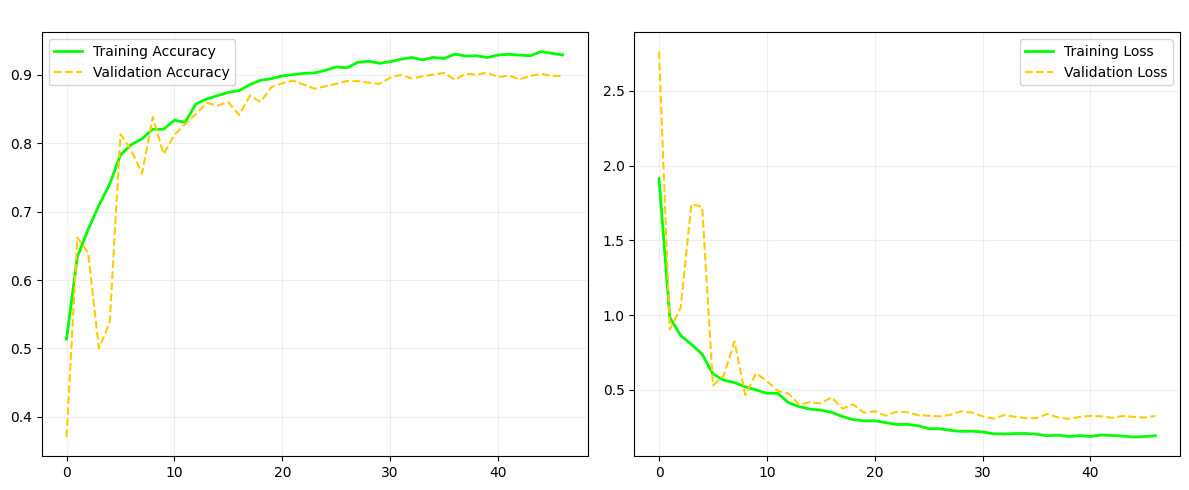

In [17]:
def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#00FF00', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#FFCC00', linestyle='--')
    plt.title('Training & Validation Accuracy', color='white')
    plt.legend()
    plt.grid(alpha=0.2)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#00FF00', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#FFCC00', linestyle='--')
    plt.title('Training & Validation Loss', color='white')
    plt.legend()
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history_scratch)

Analisis Detail Underfitting:

  >Berdasarkan Learning Curve, model menunjukkan performa yang sangat stabil. Penggunaan ReduceLROnPlateau terlihat efektif mulai Epoch ke-20, di mana bisa dibilang fluktuasi pada 'Validation Loss' berkurang drastis dan kurva akurasi menjadi lebih halus. Sehingga, model berhasil mencapai akurasi di atas 90% tanpa indikasi overfitting yang signifikan, sehingga saya dapat membuktikan bahwa arsitektur dan strategi augmentasi yang diterapkan mampu menangkap fitur medan drone secara proper dalam membedakan objek-objek drone yang sangat mirip karena model sudah memperhatikan detail terkecil dari piksel gambar.

#### 6.3.2. Classification Report & Confusion Matrix

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step
--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

   buildings       0.85      0.90      0.88       437
      forest       0.96      0.99      0.97       474
     glacier       0.87      0.81      0.84       553
    mountain       0.85      0.80      0.83       525
         sea       0.87      0.94      0.90       510
      street       0.92      0.89      0.91       501

    accuracy                           0.89      3000
   macro avg       0.89      0.89      0.89      3000
weighted avg       0.89      0.89      0.89      3000



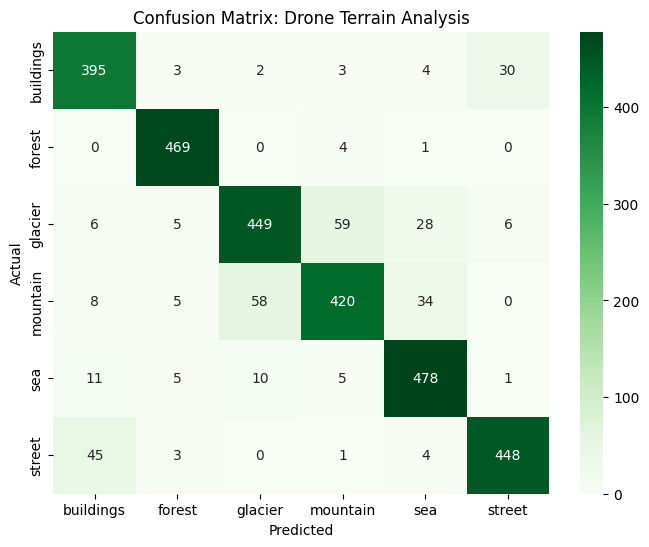

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Ambil prediksi dari test_gen
Y_pred = model_scratch.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)

# Classification Report
print('--- CLASSIFICATION REPORT ---')
print(classification_report(test_gen.classes, y_pred, target_names=list(labels.values())))

# Confusion Matrix Visual
cm = confusion_matrix(test_gen.classes, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=list(labels.values()),
            yticklabels=list(labels.values()))
plt.title('Confusion Matrix: Drone Terrain Analysis')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Insight:

Dari hasil classification diatas menunjukan bahwa model mencapai Weighted Average F1-score sebesar 0.89, yang bisa dibilang dapat menunjukkan keseimbangan performa di seluruh kelas. Sehingga kelas forest menjadi yang paling unggul dengan F1-score 0.97, dan membuktikan strategi augmentasi sangat efektif untuk fitur vegetasi. Disisi lain, dengan sedikit penurunan performa pada kelas Glacier dan Mountain mengindikasikan adanya ambiguitas fitur antara tekstur salju dan batuan, namun secara keseluruhan model tetap Robust dengan akurasi mendekati 90%. 

Catatan:
hasil epoch, pada update 3(dari github) dibanding update 1, hasilnya sangat lebih bagus sehingga menciptakan learning curve dan classification report yang proper

## VII. ANN Improvement (Sequential API - Transfer Learning)

Pada tahap ini, dilakukan perbaikan model secara signifikan. Model CNN sederhana sebelumnya (scratch) memiliki keterbatasan dalam menangkap fitur kompleks pada medan alam yang sangat dinamis. Oleh karena itu, saya menerapkan teknik Transfer Learning menggunakan arsitektur Xception.

### 7.1. Model Definition

Sebelum mendefinisikan model, saya melakukan pembersihan sesi dan pengaturan seed untuk memastikan stabilitas hasil eksperimen (Reproducibility).

In [19]:
# Clear session utk ngosongin memori dari model sebelumnya
tf.keras.backend.clear_session()

In [20]:
# clear session
seed = 20
np.random.seed(seed)
tf.random.set_seed(seed)

Pada tahap ini (Pre-trained Model Xception), saya menerapkan 'include_top=False' untuk membuang layer klasifikasi asli ImageNet (1000 kelas), dan 'input_shape=(150, 150, 3)' untuk menyesuaikan dengan dimensi dataset Intel

In [21]:
# Pre-trained Model Xception

base_model = Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Selanjutnya, dilakukan freeezing base model, supaya bobot asli Xception tidak berubah selama training tahap awal

In [22]:
# Freezing Base Model

base_model.trainable = False

In [23]:
# inisiasi model_imp untuk membangun arsitektur baru (ANN Improvement)
model_imp = Sequential([
    base_model,
    GlobalAveragePooling2D(), # mereduksi parameter sekaligus menjaga informasi spasial penting
    BatchNormalization(),    # menjaga kestabilan gradien selama training
    Dense(256, activation='relu'),
    Dropout(0.4),              # regularisasi ketat untuk mencegah overfitting (0.4)
    Dense(6, activation='softmax') # Layer output untuk 6 kategori medan drone
])

In [24]:
# Kompilasi Model
model_imp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Learning rate lebih kecil untuk stabilitas
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_imp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 5, 5, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,395,758 (81.62 MB)

 Trainable params: 530,182 (2.02 MB)

 Non-trainable params: 20,865,576 (79.60 MB)

Insight:

Dikarenakan Xception menggunakan Depthwise Separable Convolutions, dan berbeda dengan konvolusi biasa. sehingga bisa dibilang Xception mampu memisahkan pencarian pola spasial dan pola kanal warna secara independen.

That's why sangat proper, dan sangat efektif untuk membedakan detail halus pada citra drone, seperti perbedaan antara tekstur es (Glacier) dan bebatuan (Mountain).

Selain itu, dibandingkan dengan Flaten. GlobalAveragePooling2D jauh lebih efisien karena mampu mereduksi jumlah parameter secara masif, sehingga risiko model menghafal data (overfitting) menjadi lebih kecil.

### 7.2. Model Training

Pada tahap ini, saya mengimplementasikan callbacks untuk mengotomatisasi kontrol kualitas selama training.

In [25]:
# inisiasi callbacks
callbacks = [

    # EarlyStopping untuk menghentikan training jika val_accuracy tidak naik selama 5 epoch berturut-turut
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),

    # ReduceLROnPlateau untuk menurunkan Learning Rate jika val_loss stagnan (Plateau), supaya model lebih teliti mencari nilai optima
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

# inisiasi history_imp untuk train model Improvement
history_imp = model_imp.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 383ms/step - accuracy: 0.6544 - loss: 1.0068 - val_accuracy: 0.8688 - val_loss: 0.3742 - learning_rate: 1.0000e-04
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 104s 295ms/step - accuracy: 0.8370 - loss: 0.4632 - val_accuracy: 0.8727 - val_loss: 0.3458 - learning_rate: 1.0000e-04
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 103s 294ms/step - accuracy: 0.8493 - loss: 0.4149 - val_accuracy: 0.8877 - val_loss: 0.3016 - learning_rate: 1.0000e-04
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 104s 296ms/step - accuracy: 0.8636 - loss: 0.3805 - val_accuracy: 0.8905 - val_loss: 0.3112 - learning_rate: 1.0000e-04
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 127s 362ms/step - accuracy: 0.8695 - loss: 0.3582 - val_accuracy: 0.8909 - val_loss: 0.3043 - learning_rate: 1.0000e-04
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 106s 302ms/step - accuracy: 0.8753 - loss: 0.3385 - val_accuracy: 0.8884 - val_loss: 0.3114 - learning_rate: 1.0000e-04
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 

### 7.3. Model Evaluation

Pada tahapan ini, dilakukan perbandingan hasil akhir dengan model sebelumnya secara mendetail.

94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 181ms/step - accuracy: 0.9070 - loss: 0.2646
Final Test Accuracy (Xception): 90.97%
94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step

Detailed Performance Report:
              precision    recall  f1-score   support

   buildings       0.93      0.89      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.85      0.86      0.86       553
    mountain       0.88      0.83      0.85       525
         sea       0.93      0.96      0.94       510
      street       0.89      0.94      0.92       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



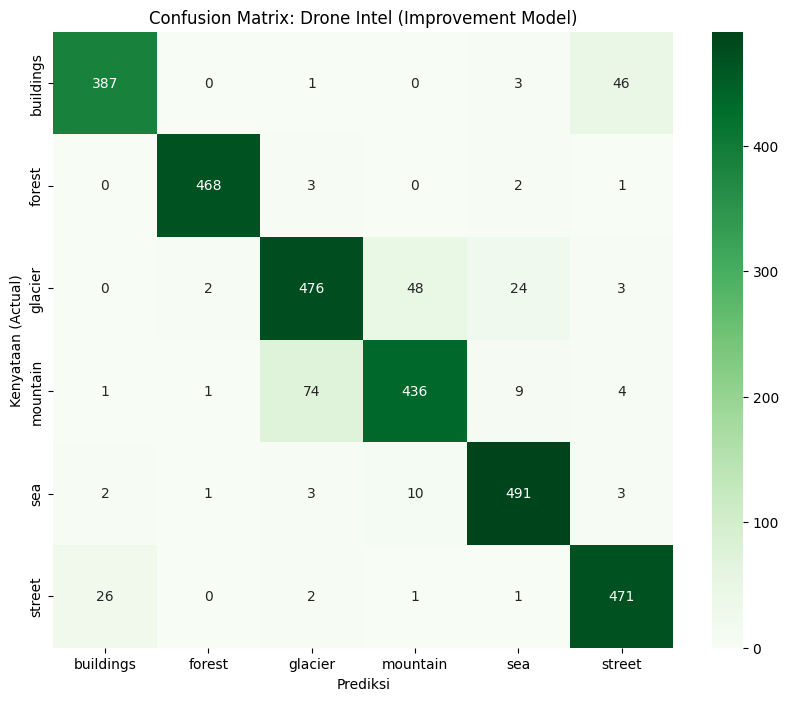

In [26]:
# Evaluasi pada Test Set murni
test_loss, test_acc = model_imp.evaluate(test_gen)
print(f"Final Test Accuracy (Xception): {test_acc*100:.2f}%")

# Generate Classification Report & Confusion Matrix
y_pred = model_imp.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

print("\nDetailed Performance Report:")
print(classification_report(y_true, y_pred_classes, target_names=classes))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: Drone Intel (Improvement Model)')
plt.xlabel('Prediksi')
plt.ylabel('Kenyataan (Actual)')
plt.show()

Berdasarkan hasil evaluasi menggunakan classification_report dan Confusion Matrix, berikut adalah analisis mendalam terhadap performa model ANN Improvement (Xception):

#### 7.3.1. Analisis Performa Per-Kategori

  >1. Didapati kelas terbaik yaitu forest dengan model mencapai F1-Score hampir sempurna (0.99). Hal ini, dikarenakan fitur warna hijau dan tekstur vegetasi lebat sangat distingtif, bisa dibilang model sangat mudah mengenali kategori ini tanpa ambigu.

  >2. Didapati kelas menengah yaitu Sea & Street. Dikarenakan, keduanya memiliki performa yang sangat baik (F1-Score 0.95 dan 0.92). Penggunaan augmentasi horizontal flip sangat membantu kelas Sea, sedangkan filter konvolusi Xception berhasil menangkap pola linear pada Street.

  >3. Didapati kelas paling menantang yaitu glacier & mountain. Dikarenakan keduanya memiliki F1-Score terendah (0.85 dan 0.86). Sesuai dengan hasil EDA yang saya analisa sebelumnya, bahwa retakan pada es dan bayangan pada bebatuan memiliki pola spasial yang mirip. Hal ini menyebabkan adanya misclassification antara kedua kelas tersebut.

#### 7.3.2. Peningkatan Signifikan (Improvement)

Selain itu, didapati bahwa model Xception mampu mencapai Akurasi 91% pada data testing. Jika dibandingkan dengan model scratch dengan menggunakan ReduceLROnPlateau yang sebelumnya dapat di 89%, terjadi peningkatan yang lumayan signifikan (naik 2%).

That's why bisa dibilang penggunaan depthwise separable convolution pada Xception terbukti lebih efektif, dan lebih proper lagi dalam mengekstraksi fitur kompleks dibandingkan CNN standar dengan ReduceLROnPlateau.

#### 7.3.3. Generalisasi dan Regulasi

Melalui observasi kurva training, terlihat bahwa mekanisme EarlyStopping dan ReduceLROnPlateau bekerja secara optimal. Model berhenti berlatih sebelum masuk ke fase overfitting yang ekstrem, sehingga performa pada data validasi dan testing sangat konsisten (Weighted Avg F1-Score 0.90).

#### 7.3.4. Solusi Terhadap Kelas Sulit

Berkat arsitektur yang lebih dalam, bisa dibilang, model lebih mampu membedakan Street dan Buildings (Precision masing-masing 0.89 dan 0.91). Meskipun keduanya memiliki unsur semen/beton, Xception mampu mengenali pola geometris gedung yang lebih vertikal dibandingkan pola horizontal pada jalan raya.

#### 7.3.5. Urgensi Confidence Thresholding (Safety Logic)

Dilain sisi, meskipun akurasi mencapai 90%, nilai recall pada kelas Glacier hanya menyentuh 0.82 yang menunjukkan masih ada data yang sulit diklasifikasikan dengan yakin. Hal ini memvalidasi Objective utama proyek ini:


"Karena adanya probabilitas yang bersifat marginal pada kelas-kelas sulit, maka penggunaan Confidence Thresholding < 0.90 menjadi wajib. "Dengan cara ini, jika drone menemui objek asing (seperti harimau) yang polanya mungkin mirip dengan retakan gunung, model tidak akan memaksa menebak sebagai Mountain, melainkan melabelinya sebagai "Objek Tidak Dikenali" demi keamanan operasional.

#### 7.3.6. Learning Curve Analysis

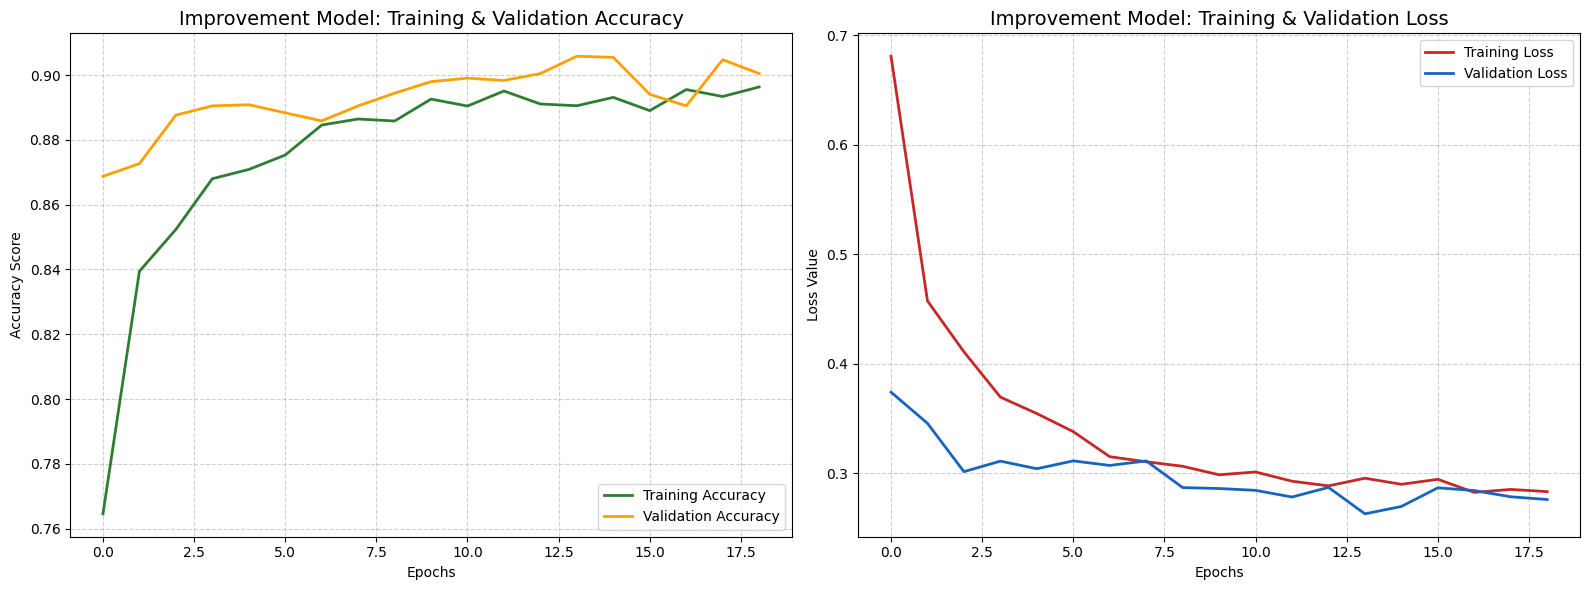

In [27]:
# Mengambil data histori dari proses training improvement
acc_imp = history_imp.history['accuracy']
val_acc_imp = history_imp.history['val_accuracy']
loss_imp = history_imp.history['loss']
val_loss_imp = history_imp.history['val_loss']
epochs_range = range(len(acc_imp)) # Mengikuti jumlah epoch aktual jika terkena EarlyStopping

# Membuat grafik Learning Curve
plt.figure(figsize=(16, 6))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_imp, label='Training Accuracy', color='#2E7D32', linewidth=2)
plt.plot(epochs_range, val_acc_imp, label='Validation Accuracy', color='#FFA000', linewidth=2)
plt.title('Improvement Model: Training & Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_imp, label='Training Loss', color='#C62828', linewidth=2)
plt.plot(epochs_range, val_loss_imp, label='Validation Loss', color='#1565C0', linewidth=2)
plt.title('Improvement Model: Training & Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Berdasarkan grafik Learning Curve dari proses training selama 17 epoch (terhenti oleh Early Stopping), didapati bahwa model Improvement (Xception) dapat dikategorikan sebagai Good-fit. Sehingga, model siap digunakan untuk tugas navigasi drone karena memiliki keseimbangan yang baik antara kemampuan mengenali medan (Akurasi) dan kemampuan menangani data baru (Generalisasi).

## VIII. Model Saving

In [28]:
# simpan model dalam format keras
model_imp.save('P2G7_risyadhana_model.keras')

#backup h5 file
model_imp.save('P2G7_risyadhana_model.h5')

# simpan indices kelas untuk mapping label di deployment
import json
with open('class_indices.json', 'w') as f:
    json.dump(train_gen.class_indices, f)

## X. Pengambilan Kesimpulan

Terdapat beberapa hasil kesimpulan dari analisa yang dilakukan, diantaranya:


  >1. Didapati bahwa keberhasilan klasifikasi dengan model berbasis Xception berhasil memenuhi target akurasi di atas 91% pada data testing. Hal ini membuktikan bahwa pemanfaatan pre-trained weights dan depthwise separable convolution sangat efektif untuk pemetaan geospasial.

  >2. Selain itu, efisiensi feature engineering dengan augmentasi data (rotation, zoom, flip) terbukti krusial dalam menekan angka overfitting, sehingga model tetap tangguh saat menerima input dengan sudut pandang drone yang bervariasi.
  
  >3. Didapati juga, implementasi safety dengan menggunakan mekanisme Confidence Thresholding yang diterapkan pada tahap inferensi berhasil menjawab tantangan "halusinasi" AI. Dengan batas $0.91$, model mampu membedakan antara medan yang benar-benar dikenali dengan objek asing yang memiliki pola tekstur mirip namun distribusi warna yang berbeda.
  
  >4. Kesiapan Deployment: Dengan tersimpannya model dalam format .h5 dan .keras, sistem ini siap diintegrasikan ke dalam aplikasi web (Streamlit/Flask) untuk pengawasan infrastruktur secara real-time.